In [4]:
import pandas as pd
df = pd.read_csv("upi_fraud_dataset.csv")

In [5]:
x = df.drop('Fraud', axis=1)
y = df['Fraud']

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 12)
(2000, 12)
(8000,)
(2000,)


In [7]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
from sklearn.metrics import classification_report
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95       374
           1       0.98      1.00      0.99      1626

    accuracy                           0.98      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.98      0.98      0.98      2000



In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 342   32]
 [   5 1621]]


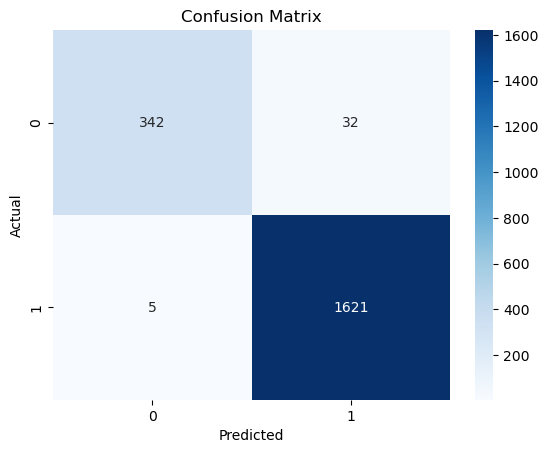

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance.head(10))

                    Feature  Importance
1        Transaction_Amount    0.143447
11         Account_Verified    0.138797
3   Transactions_Last_24Hrs    0.132016
4       Failed_Transactions    0.107052
6            Device_Changed    0.090039
7          Location_Changed    0.089989
2          Transaction_Time    0.070746
10           Fraud_Reported    0.068016
0              UPI_Age_Days    0.053836
5             New_Recipient    0.047965


In [17]:
f = [[12234,1213245,23,24,0,0,0,0,0,0,0,0]]

test = rf.predict(f)
print(test)

[1]


C:\Users\KIIT\Videos\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
